In [85]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("df_hmm_var.csv", parse_dates=["date"])
df["rvar_lag1"] = df["realized_variance"].shift(1)
df["rvar_lag2"] = df["realized_variance"].shift(2)
df["rvar_lag3"] = df["realized_variance"].shift(3)
df_clean = df.dropna(subset=['hmm_regime', 'hmm_prob_high']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3489, 52)

Regime distribution:
hmm_regime
0.0    1975
1.0    1149
Name: count, dtype: int64


In [86]:
svr_features = [
    "log_return",
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg",
    "rvar_7",
    "rvar_30",
    "rvar_lag1",
    "rvar_lag2",
    "rvar_lag3",
    "hmm_prob_high"#,
    #"hmm_prob_high_lag1",
    #"hmm_prob_high_lag2",
    #"hmm_prob_high_roll5"
]
print(f"\nTotal SVR features: {len(svr_features)}")



Total SVR features: 34


In [ ]:
# Define clipping 
# floor: rolling mean 5 for predicted variance
#df_clean["var_floor_5"] = df_clean["target_var"].shift(1).rolling(5, min_periods=5).mean()
# global upper bound
upper_bound = df_clean["target_var"].quantile(0.995)

#def clip_variance_pred(pred, floor_val, upper_bound):
#    if pd.isna(floor_val):
#        floor_val = 1e-8
#    else:
#        floor_val = max(1e-8, floor_val)
#    return np.clip(pred, floor_val, upper_bound)

In [88]:
# 60/25/15 split
total_len = len(df_clean)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df_clean['date'].iloc[0]} to {df_clean['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df_clean['date'].iloc[val_start]} to {df_clean['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df_clean['date'].iloc[test_start]} to {df_clean['date'].iloc[-1]}")

window_size = 365

Train:    0 to 1874 (1874 days) | 2017-07-13 00:00:00 to 2022-08-29 00:00:00
Val:   1874 to 2655 ( 781 days) | 2022-08-30 00:00:00 to 2024-10-18 00:00:00
Test:  2655 to 3124 ( 469 days) | 2024-10-19 00:00:00 to 2026-01-30 00:00:00


In [ ]:
# Grid search for C and epsilon and gamma
C_values = [0.1, 1.0, 10.0]
epsilon_values = [0.00001, 0.0001, 0.001, 0.01]
gamma_values = ["scale", 0.1]

val_sample_indices = range(val_start, val_end, 5)
valid_indices = [i for i in val_sample_indices if i >= window_size]
grid_results = []
total_configs = len(C_values) * len(epsilon_values) * len(gamma_values)

print(f"Testing {total_configs} configurations on {len(valid_indices)} samples...")
print(f"Total features: {len(svr_features)}")
print(f"Window size: {window_size} days")

config_num = 0

for C, epsilon, gamma in product(C_values, epsilon_values, gamma_values):
    config_num += 1
    
    preds = []
    actuals = []
    
    for i in valid_indices:
        train_X = df_clean.iloc[i - window_size : i][svr_features].values
        train_y = df_clean.iloc[i - window_size : i]['target_var'].values
        
        test_X = df_clean.iloc[i:i+1][svr_features].values
        target_val = df_clean.iloc[i]['target_var']
        
        try:
            # Scale features AND target
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            train_X_scaled = scaler_X.fit_transform(train_X)
            train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
            test_X_scaled = scaler_X.transform(test_X)
            
            # Fit SVR with hyperparameters
            model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma= gamma, max_iter=1000) 
            model.fit(train_X_scaled, train_y_scaled)
            
            # Predict and inverse transform
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]

            #clip
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            pred = np.clip(pred, 1e-7, upper_bound)

            preds.append(pred)
            actuals.append(target_val)
            
        except Exception as e:
            fallback = preds[-1] if preds else 0 
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        grid_results.append({'C': C, 'epsilon': epsilon,'gamma': gamma, 'RMSE': rmse})
    
    print(f"Config {config_num}/{total_configs}: C={C:6.1f}, ε={epsilon:5.3f}, RMSE={rmse:.8f} | ")

results_df = pd.DataFrame(grid_results).sort_values('RMSE')

print("\n" + "="*60)
print("TOP 10 CONFIGURATIONS")
print("="*60)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_C = best_config['C']
best_epsilon = best_config['epsilon']
best_gamma = best_config['gamma']

print(f"\n" + "="*60)
print("BEST CONFIGURATION")
print("="*60)
print(f"C:       {best_C}")
print(f"epsilon: {best_epsilon}")
print(f"gamma: {best_gamma}")
print(f"Validation RMSE: {best_config['RMSE']:.8f}")
print("="*60)

Testing 24 configurations on 157 samples...
Total features: 34
Window size: 365 days
Config 1/24: C=   0.1, ε=0.000, RMSE=0.00097349 | 
Config 2/24: C=   0.1, ε=0.000, RMSE=0.00100505 | 
Config 3/24: C=   0.1, ε=0.000, RMSE=0.00097346 | 
Config 4/24: C=   0.1, ε=0.000, RMSE=0.00100505 | 
Config 5/24: C=   0.1, ε=0.001, RMSE=0.00097346 | 
Config 6/24: C=   0.1, ε=0.001, RMSE=0.00100505 | 
Config 7/24: C=   0.1, ε=0.010, RMSE=0.00097361 | 
Config 8/24: C=   0.1, ε=0.010, RMSE=0.00100510 | 
Config 9/24: C=   1.0, ε=0.000, RMSE=0.00093722 | 
Config 10/24: C=   1.0, ε=0.000, RMSE=0.00094777 | 
Config 11/24: C=   1.0, ε=0.000, RMSE=0.00093721 | 
Config 12/24: C=   1.0, ε=0.000, RMSE=0.00094777 | 
Config 13/24: C=   1.0, ε=0.001, RMSE=0.00093720 | 
Config 14/24: C=   1.0, ε=0.001, RMSE=0.00094781 | 
Config 15/24: C=   1.0, ε=0.010, RMSE=0.00093715 | 
Config 16/24: C=   1.0, ε=0.010, RMSE=0.00094818 | 
Config 17/24: C=  10.0, ε=0.000, RMSE=0.00094337 | 
Config 18/24: C=  10.0, ε=0.000, RMSE=0.

In [ ]:
#best_C = 1.0
#best_epsilon = 0.01
#gamma = "scale"

In [ ]:
val_preds = []
val_actuals = []
val_dates = []
failures = 0

print(f"\nRunning full validation with C={best_C}, epsilon={best_epsilon}, gamma={best_gamma}...")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='rbf', C=best_C, epsilon=best_epsilon, gamma = best_gamma)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 1e-7, upper_bound)
        
        val_preds.append(pred)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)


Running full validation with C=1.0, epsilon=0.01, gamma=scale...


In [92]:
val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)


print(f"\n--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE:   {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


--- VALIDATION RESULTS ---
RMSE:  0.000882
MAE:   0.000456
QLIKE:   1.129244
Failures: 0
Samples: 781


In [ ]:
test_preds = []
test_actuals = []
test_dates = []
failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='rbf', C=best_C, epsilon=best_epsilon, gamma = best_gamma)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 1e-7, upper_bound)
        
        test_preds.append(pred)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)


Running test set evaluation...


In [94]:
test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE:   {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


--- TEST RESULTS ---
RMSE:  0.000640
MAE:   0.000371
QLIKE:   13.520371
Failures: 0
Samples: 469


In [95]:
summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike,test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-RBF Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  C: {best_C}")
print(f"  epsilon: {best_epsilon}")
print(f"  gamma: {best_gamma}")
print(f"  Features: {len(svr_features)}")
print("="*60)

# Save results
val_results = pd.DataFrame({
    'date': val_dates,
    'actual': val_actuals,
    'forecast': val_preds,
    'error': val_actuals - val_preds
})

test_results = pd.DataFrame({
    'date': test_dates,
    'actual': test_actuals,
    'forecast': test_preds,
    'error': test_actuals - test_preds
})



HMM-SVR-RBF Summary
   Dataset     RMSE      MAE     QLIKE  Samples
Validation 0.000882 0.000456  1.129244      781
      Test 0.000640 0.000371 13.520371      469

Best Parameters Used:
  C: 1.0
  epsilon: 0.01
  gamma: scale
  Features: 34


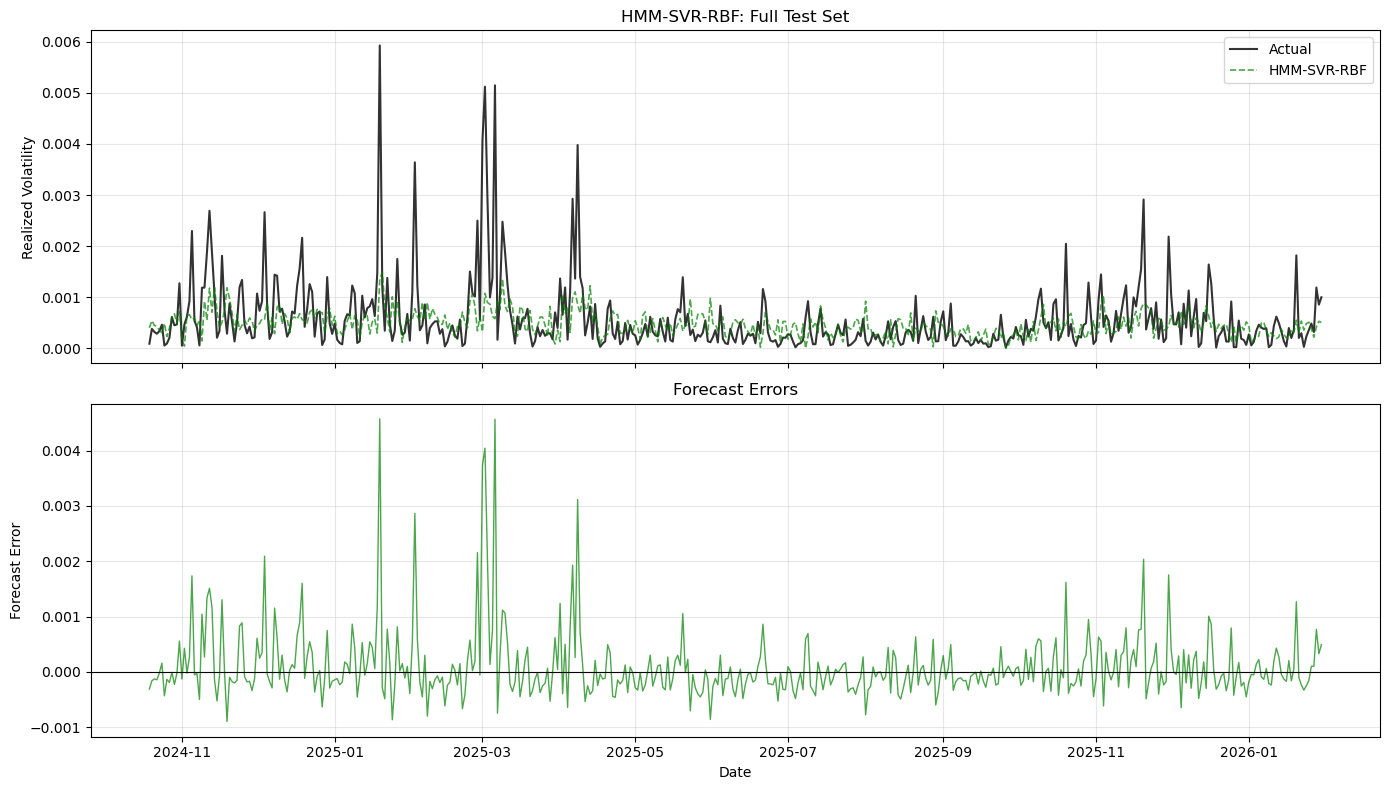

In [96]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = len(test_actuals)
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-RBF', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Volatility')
axes[0].set_title(f'HMM-SVR-RBF: Full Test Set')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

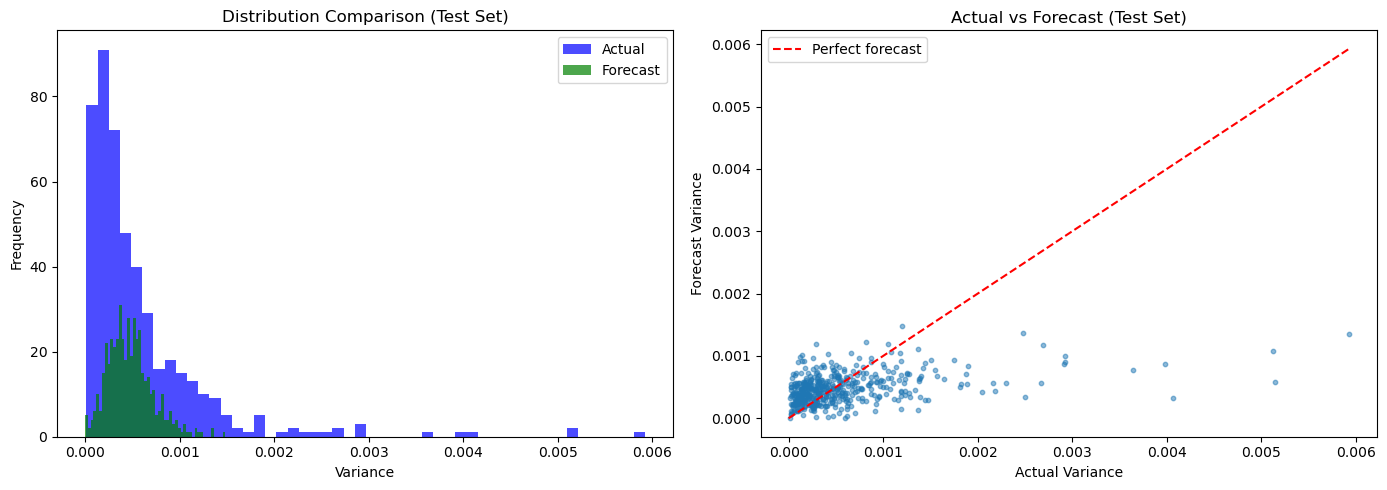


Forecast Statistics (Test Set):
  Mean forecast: 0.000477
  Mean actual:   0.000571
  Forecast std:  0.000238
  Actual std:    0.000689
  Forecasts > Actuals: 57.1%


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Variance')
axes[1].set_ylabel('Forecast Variance')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")

In [98]:
pred_var = np.maximum(test_preds, 1e-10)
actual_var = np.maximum(test_actuals, 1e-10)
qlike_i = actual_var / pred_var - np.log(actual_var / pred_var) - 1

print("Mean QLIKE:", np.mean(qlike_i))
print("Median QLIKE:", np.median(qlike_i))
print("Max QLIKE:", np.max(qlike_i))

qlike_df = pd.DataFrame({
    "date": test_dates,
    "actual_var": actual_var,
    "pred_var": pred_var,
    "qlike": qlike_i
}).sort_values("qlike", ascending=False)

print(qlike_df.head(10))
print("Share pred < 1e-8:", np.mean(pred_var < 1e-8))
print("Share pred < 1e-7:", np.mean(pred_var < 1e-7))
print("Share pred < 1e-6:", np.mean(pred_var < 1e-6))

Mean QLIKE: 13.53334897783297
Median QLIKE: 0.201608974455048
Max QLIKE: 5903.617204953735
          date  actual_var      pred_var        qlike
262 2025-07-08    0.000591  1.000000e-07  5903.617205
342 2025-09-26    0.000018  1.000000e-07   174.996144
313 2025-08-28    0.000618  2.870059e-05    17.451257
297 2025-08-12    0.000417  2.689580e-05    11.755940
244 2025-06-20    0.000295  1.927968e-05    11.572334
133 2025-03-01    0.004062  3.266053e-04     8.916175
14  2024-11-02    0.000469  4.232925e-05     7.676229
164 2025-04-01    0.001367  1.278593e-04     7.319794
138 2025-03-06    0.005147  5.800008e-04     5.691516
162 2025-03-30    0.000703  8.302692e-05     5.330326
Share pred < 1e-8: 0.0
Share pred < 1e-7: 0.0
Share pred < 1e-6: 0.0042643923240938165
